---
# Multipolar kick visulation
---

(Plotting the "shadow" of the tori can take a few minutesm depending on the number in `T_vals`)

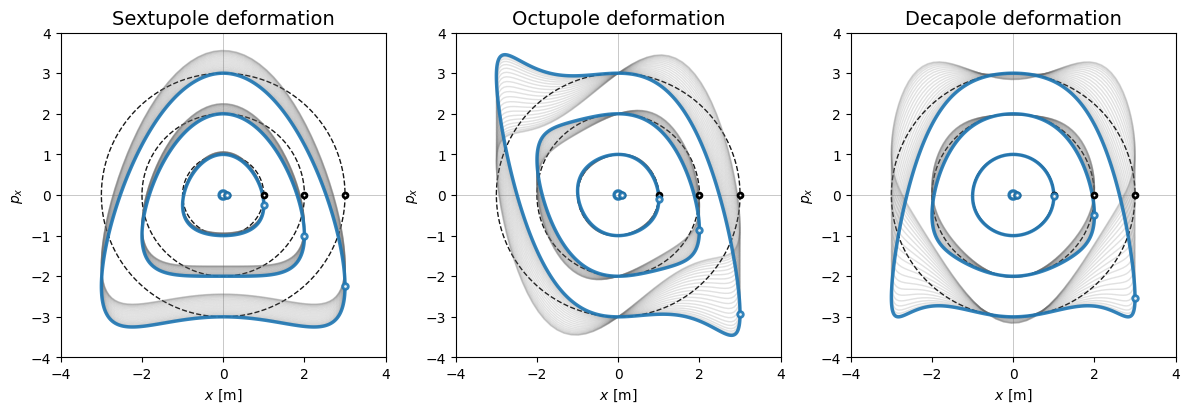

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt


#============================
# Parameters
#============================
rxvec = np.array([0.1,1,2,3])
ryvec = np.array([0.1,1,2,3])/2

base_tori = []
for rx,ry in zip(rxvec ,ryvec ):
    base_tori.append(pt.Torus(x={(1,0):rx},
                              y={(0,1):ry}))
#-----------------------------



T_fixed =  {    'Tx':np.linspace(0,2*np.pi,500),
                'Ty':np.pi/2}

fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax,label,knl in zip(axes,['sextupole',
                              'octupole',
                              'decapole']
                              ,[[0,0,0.5],
                                [0,0,0,0.65],
                                [0,0,0,0,0.75],
                                    ]):

    
    plt.sca(ax)
    plt.title(f'{label.capitalize()} deformation',fontsize=14)
    for torus in base_tori:
        Psi = torus.copy()

        # Plotting before transformation
        #=======================================================
        ptplt.loop(Psi,proj='x',**T_fixed,edgecolor='k',ls='--',alpha=0.9,lw=1)
        plt.plot(Psi.X(0,Ty=np.pi/2),Psi.PX(0,Ty=np.pi/2),'o',ms=3.5,alpha=1,mec='k',mew=2,color='w',zorder=10)
        

        # Applying multipole transformation
        #=======================================================
        Psi = pt.transforms.multipole(Psi,knl=knl)


        # TORUS SHADOW, plotting all possible angle values
        #=======================================================
        T_loop = np.linspace(0,2*np.pi,100)
        T_vals = np.linspace(0,2*np.pi,50)
        for T0 in T_vals[:-1]:
            ptplt.loop(Psi,proj='x',Tx=T_loop,Ty=T0,edgecolor='dimgrey',alpha=0.1,lw=1)
        #=======================================================

        # Plotting a specific loop
        #=======================================================
        ptplt.loop(Psi,proj='x',**T_fixed,edgecolor='C0',alpha=0.9,lw=2.5)
        plt.plot(Psi.X(0,Ty=np.pi/2),Psi.PX(0,Ty=np.pi/2),'o',ms=4,alpha=0.9,mec='C0',mew=2,color='w',zorder=10)
        

    plt.axhline(0,color='k',ls='-',alpha=0.3,lw=0.5,zorder=-10)
    plt.axvline(0,color='k',ls='-',alpha=0.3,lw=0.5,zorder=-10)

    plt.axis('equal')
    plt.gca().set_box_aspect(1) 
    plt.xlabel(r'$x\ [\mathrm{m}]$');
    plt.ylabel(r'$p_x$');

    lims = 4
    plt.xlim(-lims,lims)
    plt.ylim(-lims,lims)
 
plt.tight_layout()

---
# Particle analog (via Xsuite)
---

##### N.B.: the multipolar kick of `pt.transforms` is mathematically identical to Xsuite's

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


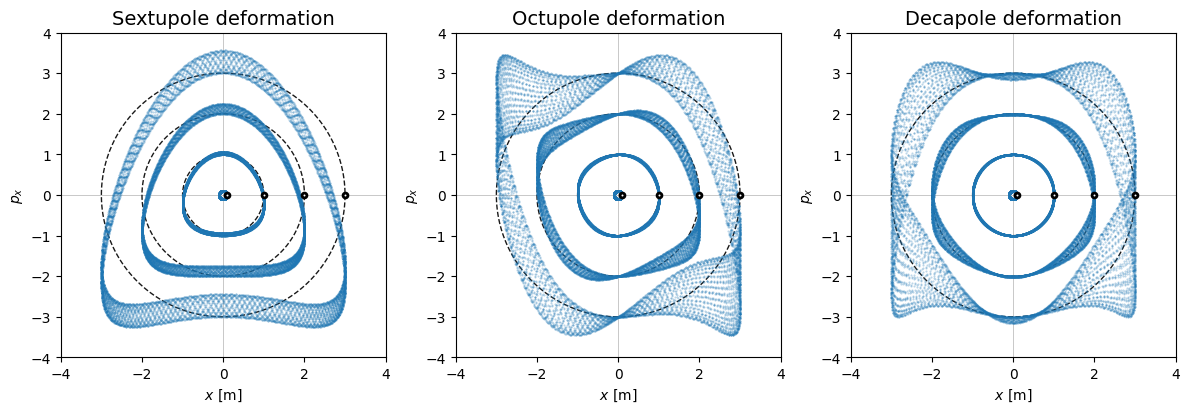

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

import xtrack as xt
import xobjects as xo

#============================
# Parameters
#============================
rxvec = np.array([0.1,1,2,3])
ryvec = np.array([0.1,1,2,3])/2

base_tori = []
for rx,ry in zip(rxvec ,ryvec ):
    base_tori.append(pt.Torus(x={(1,0):rx},
                              y={(0,1):ry}))
#-----------------------------

# For particle creation
#==========================================
# Irrationnal and non-resonant frequencies
#-------------------------------
fx  = 1/2/np.sqrt(2)
fy  = 1/2/np.sqrt(3)
#-------------------------------
num_particles = int(1e4)
T_dict =  { 'Tx':2*np.pi*fx*np.arange(num_particles),
            'Ty':2*np.pi*fy*np.arange(num_particles)}
#-------------------------------
#==========================================

T_fixed =  {    'Tx':np.linspace(0,2*np.pi,500),
                'Ty':np.pi/2}
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax,label,knl in zip(axes,['sextupole',
                              'octupole',
                              'decapole']
                              ,[[0,0,0.5],
                                [0,0,0,0.65],
                                [0,0,0,0,0.75],
                                    ]):

    
    plt.sca(ax)
    plt.title(f'{label.capitalize()} deformation',fontsize=14)
    for torus in base_tori:
        Psi = torus.copy()

        # Plotting before transformation
        #=======================================================
        ptplt.loop(Psi,proj='x',**T_fixed,edgecolor='k',ls='--',alpha=0.9,lw=1)
        plt.plot(Psi.X(0,Ty=np.pi/2),Psi.PX(0,Ty=np.pi/2),'o',ms=3.5,alpha=1,mec='k',mew=2,color='w',zorder=10)
        

        # Tracking particles through xsuite multipole:
        particles = xt.Particles(x=Psi.X(**T_dict),
                                px=Psi.PX(**T_dict),
                                y=Psi.Y(**T_dict),
                                py=Psi.PY(**T_dict))

        ee = xt.Multipole(knl=knl,length=0)
        ee.track(particles)

        # Plotting particles
        plt.plot(particles.x,particles.px,'.',ms=1,alpha=0.3,color='C0')

    plt.axhline(0,color='k',ls='-',alpha=0.3,lw=0.5,zorder=-10)
    plt.axvline(0,color='k',ls='-',alpha=0.3,lw=0.5,zorder=-10)

    plt.axis('equal')
    plt.gca().set_box_aspect(1) 
    plt.xlabel(r'$x\ [\mathrm{m}]$');
    plt.ylabel(r'$p_x$');

    lims = 4
    plt.xlim(-lims,lims)
    plt.ylim(-lims,lims)
 
plt.tight_layout()